## Practica 5: latent space of the Auto-Encoder
### In this practice, you will use the image sample MNIST, which is composed of numbers. This famous library is directly included inside the tensorflow package :

In [24]:
import tensorflow as tf
#from tensorflow import kerasi
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
mnist = keras.datasets.mnist

### You will generate an autoencoder that allows to reproduce the images with a pretty good fidelity before analysing the latent layer in order to extract the information to classify these numbers. This study will be done at different levels:
* Direct k-means 
* GMM

## 1 Exercise: Construct and train your Auto-Encoder
### 1.1 Generation of training set and validation set

In [3]:
# Read the data from MNIST and separate the whole sample into 3 as follows:
# 1. 55000 for the training set
# 2. 10000 for the validation set
# 3. 5000 for the test set

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_val = x_train[:55000], x_train[55000:]
y_train, y_val = y_train[:55000], y_train[55000:]
x_test, y_test = x_test[:5000], y_test[:5000]
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(55000, 28, 28) (55000,)
(5000, 28, 28) (5000,)
(5000, 28, 28) (5000,)


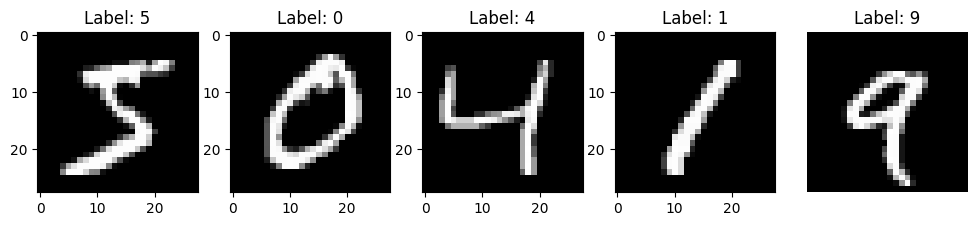

In [18]:
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
plt.axis('off')
plt.show()  

#### Here "x_train" constains the images and "y_train" contains the labels of these images. The same applies for the validation and test sets. You can see that the images are in grayscale and have a size of 28x28 pixels. The labels are integers from 0 to 9, representing the digit in the image. The test set will be important for this practice for evaluating the performance of your classification after using the validation for constructing your classifier.
* In order to help your training, we recommend that you normalize the pictures pixel values between 0 and 1.
* Also, no forget to use the "flatten()" method in order to transform the (28,28) shape into (1, 764) You can use a latent layer with 20 neurons as a suggestion.
* Your goal will be to reach at least 1% on the validation set loss function using a mean squared error or mean
absolute error.
#### For this stage:
1) Explain your choice of architecture, and activation functions.
2) Plot the loss function evolution.
3) Using your autoencoder, encode the validation set that you will save in a variable "encoded_imgs".
4) Chose 10 examples from "encoded_imgs" that you will decode using your autoencoder.
5) Using the "imshow()" function, plot the decoded images obtained comparing them to the original images.


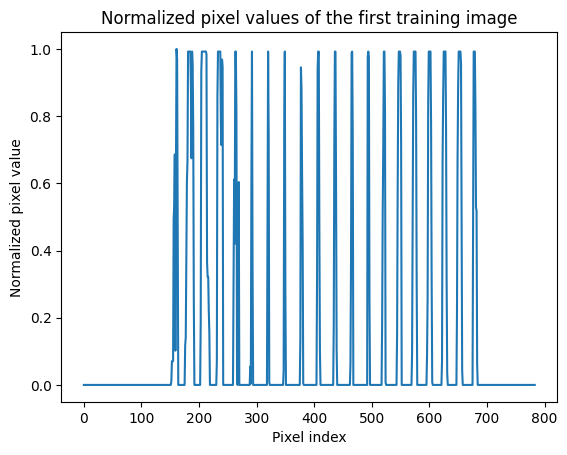

In [26]:
# First,let's normalize the data to be in the range [0, 1] and reshape it to fit the input of the autoencoder.

x_train_norm = MinMaxScaler().fit_transform(x_train.reshape(-1, 28*28))
x_val_norm = MinMaxScaler().fit_transform(x_val.reshape(-1, 28*28))
x_test_norm = MinMaxScaler().fit_transform(x_test.reshape(-1, 28*28))

plt.plot(x_train_norm[0])
plt.title("Normalized pixel values of the first training image")
plt.xlabel("Pixel index")
plt.ylabel("Normalized pixel value")
plt.show()